<a href="https://colab.research.google.com/github/annashabba/habbaanas/blob/main/UTS_DATA_MINING_Habba_Arrizal_Anas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)
import warnings
warnings.filterwarnings('ignore')

Pada tahap ini dilakukan import library yang digunakan selama proses analisis data dan machine learning. pandas digunakan untuk membaca dan mengolah dataset dalam bentuk tabel.
numpy digunakan untuk operasi numerik dan perhitungan matematika.
matplotlib.pyplot digunakan untuk visualisasi data seperti grafik distribusi dan perbandingan model. Library ini digunakan untuk preprocessing data. train_test_split digunakan untuk membagi dataset menjadi data training dan validation.
StandardScaler digunakan untuk melakukan normalisasi/scaling data agar semua fitur memiliki skala yang seragam. Library tersebut digunakan untuk membangun model klasifikasi.
RandomForestClassifier merupakan algoritma ensemble berbasis decision tree.
KNeighborsClassifier merupakan algoritma klasifikasi berdasarkan kedekatan jarak antar data.
LogisticRegression merupakan algoritma klasifikasi linear. Digunakan untuk evaluasi performa model.
accuracy_score digunakan untuk menghitung tingkat ketepatan prediksi model.
confusion_matrix digunakan untuk melihat jumlah prediksi benar dan salah pada setiap kelas.
classification_report digunakan untuk melihat precision, recall, dan f1-score.

In [54]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

Kode tersebut digunakan agar seluruh baris dan kolom dataset dapat ditampilkan tanpa dipotong.
Hal ini memudahkan proses pengecekan data secara menyeluruh.

In [55]:
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

Dataset training dan testing dibaca menggunakan pandas.
data_training.csv digunakan untuk melatih model.
data_testing.csv digunakan untuk prediksi kualitas wine.

In [56]:
print("===== DATA TRAINING =====")
print(train)

===== DATA TRAINING =====
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0              7.3             0.740         0.08            1.70      0.094   
1              8.1             0.575         0.22            2.10      0.077   
2             10.1             0.430         0.40            2.60      0.092   
3             12.9             0.500         0.55            2.80      0.072   
4              8.4             0.360         0.32            2.20      0.081   
5              9.6             0.600         0.50            2.30      0.079   
6              8.5             0.320         0.42            2.30      0.075   
7              6.9             0.490         0.19            1.70      0.079   
8              6.0             0.510         0.00            2.10      0.064   
9              8.1             0.825         0.24            2.10      0.084   
10             8.5             0.180         0.51            1.75      0.071   
11            

In [57]:
print("===== DATA TESTING =====")
print(test)

===== DATA TESTING =====
     fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0              6.8             0.610         0.04            1.50      0.057   
1              6.9             0.840         0.21            4.10      0.074   
2              7.0             0.580         0.12            1.90      0.091   
3              7.8             0.480         0.68            1.70      0.415   
4             12.5             0.600         0.49            4.30      0.100   
5              7.9             0.540         0.34            2.50      0.076   
6              8.8             0.610         0.14            2.40      0.067   
7              7.4             0.500         0.47            2.00      0.086   
8              7.6             0.410         0.14            3.00      0.087   
9              9.0             0.450         0.49            2.60      0.084   
10            10.4             0.440         0.73            6.55      0.074   
11             

Digunakan untuk menampilkan seluruh isi dataset sehingga dapat diketahui struktur data dan fitur yang tersedia.

In [58]:
print("\n===== DIMENSI DATA =====")

print("Shape Data Training:")
print(train.shape)

print("\nShape Data Testing:")
print(test.shape)


===== DIMENSI DATA =====
Shape Data Training:
(857, 13)

Shape Data Testing:
(286, 12)


Digunakan untuk mengetahui jumlah:

baris (data)
kolom (fitur)

Semakin banyak data training maka model biasanya semakin baik dalam mempelajari pola data.

In [59]:
print("\n===== INFORMASI DATASET =====")

print(train.info())


===== INFORMASI DATASET =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB
None


Digunakan untuk melihat:

tipe data setiap fitur
jumlah data non-null
struktur dataset

Hasil menunjukkan bahwa seluruh fitur bertipe numerik sehingga dapat langsung digunakan untuk machine learning.

In [60]:
print("\n===== STATISTIK DESKRIPTIF =====")

print(train.describe())


===== STATISTIK DESKRIPTIF =====
       fixed acidity  volatile acidity  citric acid  residual sugar  \
count     857.000000        857.000000   857.000000      857.000000   
mean        8.261960          0.529393     0.267351        2.506184   
std         1.701992          0.179162     0.195144        1.293512   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.395000     0.090000        1.900000   
50%         7.900000          0.520000     0.250000        2.200000   
75%         9.100000          0.640000     0.420000        2.600000   
max        15.600000          1.580000     1.000000       15.500000   

        chlorides  free sulfur dioxide  total sulfur dioxide     density  \
count  857.000000           857.000000            857.000000  857.000000   
mean     0.086830            15.782964             45.978413    0.996692   
std      0.048721            10.300402             31.692113    0.001901   
min      0.012000     

Digunakan untuk melihat statistik dasar dari dataset seperti:

rata-rata
standar deviasi
nilai minimum
nilai maksimum

Tahap ini membantu memahami karakteristik data dan mendeteksi kemungkinan outlier.

In [61]:
print("\n===== MISSING VALUES =====")

print(train.isnull().sum())


===== MISSING VALUES =====
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64


Digunakan untuk mengecek apakah terdapat data kosong (missing values).

Jika terdapat missing values maka perlu dilakukan:

imputasi data
atau penghapusan data

Pada dataset ini tidak ditemukan missing values sehingga data dapat langsung digunakan.

In [62]:
print("\n===== DATA DUPLIKAT =====")

print(train.duplicated().sum())


===== DATA DUPLIKAT =====
0


Digunakan untuk mengecek apakah terdapat data yang sama persis.

Data duplikat dapat menyebabkan model menjadi bias karena data tertentu muncul berulang.

In [63]:
train = train.drop_duplicates()

Data duplikat dihapus agar kualitas dataset menjadi lebih baik dan model tidak mengalami bias.


===== DISTRIBUSI QUALITY =====
quality
3      6
4     26
5    362
6    341
7    109
8     13
Name: count, dtype: int64


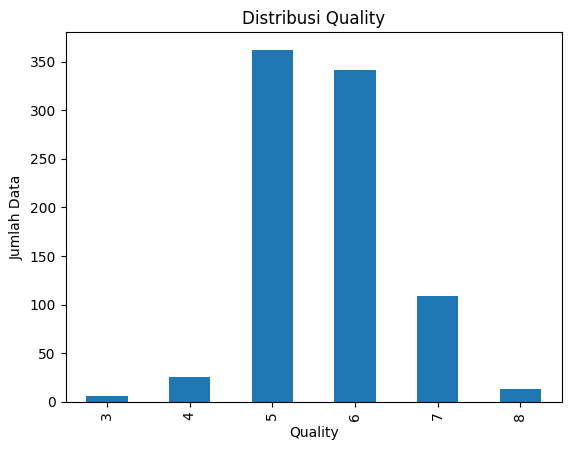

In [64]:
print("\n===== DISTRIBUSI QUALITY =====")

print(train['quality'].value_counts().sort_index())
train['quality'].value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Distribusi Quality')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.show()

Digunakan untuk melihat jumlah masing-masing kelas quality.

Hasil menunjukkan bahwa:

quality 5 dan 6 memiliki jumlah data paling banyak
distribusi kelas tidak sepenuhnya seimbang
Visualisasi grafik batang digunakan agar distribusi kelas lebih mudah dipahami secara visual.

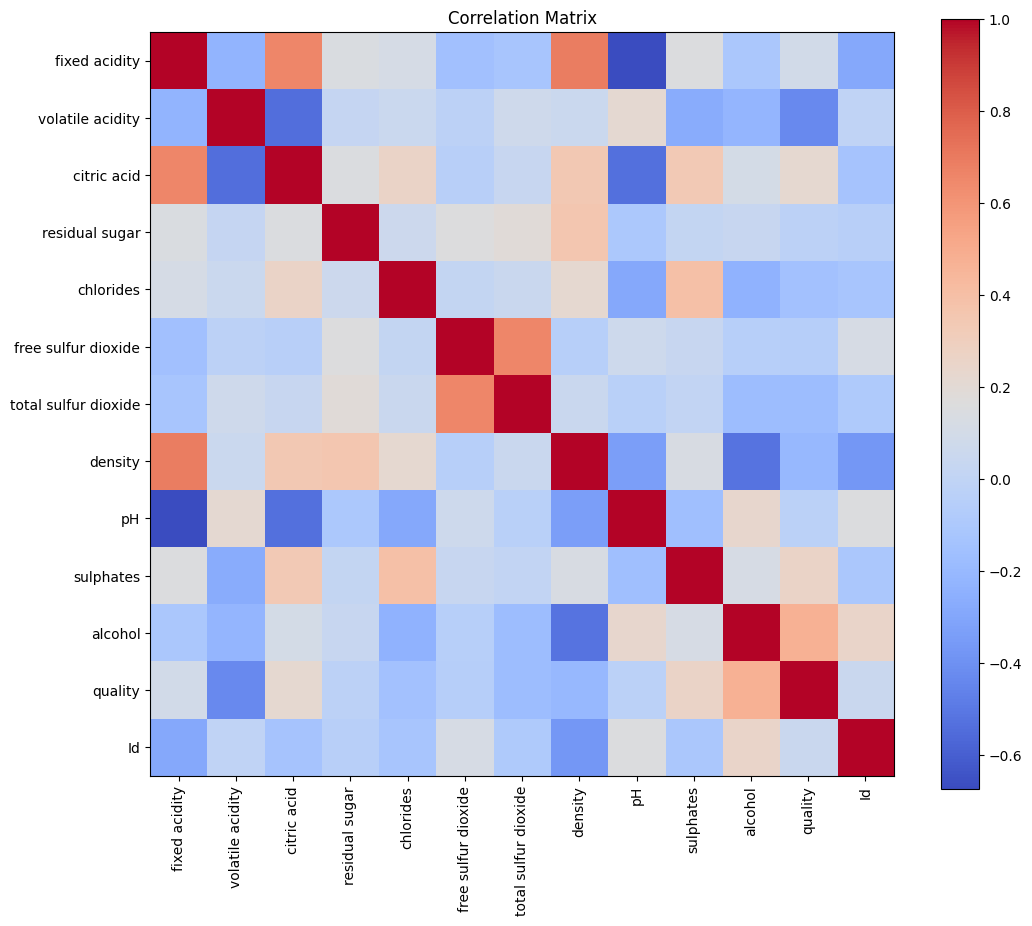

In [65]:
corr = train.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr, cmap='coolwarm')

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title('Correlation Matrix')

plt.show()

Digunakan untuk menghitung hubungan antar variabel.

Korelasi membantu mengetahui fitur yang memiliki pengaruh terhadap kualitas wine.
Heatmap korelasi digunakan untuk memvisualisasikan kekuatan hubungan antar fitur.

Warna merah menunjukkan korelasi positif
Warna biru menunjukkan korelasi negatif

In [66]:
X = train.drop(['quality', 'Id'], axis=1)

y = train['quality']

Dataset dipisahkan menjadi:

X → fitur/variabel input
y → target yang akan diprediksi yaitu quality

In [67]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\n===== SPLIT DATA =====")

print("Jumlah X_train :", X_train.shape)
print("Jumlah X_val   :", X_val.shape)


===== SPLIT DATA =====
Jumlah X_train : (685, 11)
Jumlah X_val   : (172, 11)


Dataset dibagi menjadi:

80% data training
20% data validation

Parameter:

random_state=42 digunakan agar hasil split konsisten
stratify=y digunakan agar distribusi kelas tetap seimbang

In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

Feature scaling dilakukan agar semua fitur memiliki skala yang seragam.

Hal ini penting terutama untuk algoritma:

KNN
Logistic Regression

In [69]:
print("\n===== RANDOM FOREST =====")

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_val)
rf_acc = accuracy_score(y_val, rf_pred)

print("Accuracy Random Forest:")
print(rf_acc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, rf_pred))
print("\nClassification Report:")
print(classification_report(y_val, rf_pred))


===== RANDOM FOREST =====
Accuracy Random Forest:
0.6046511627906976

Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  0 58 14  1  0]
 [ 0  0 25 39  4  0]
 [ 0  0  0 16  6  0]
 [ 0  0  0  0  2  1]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.66      0.79      0.72        73
           6       0.56      0.57      0.57        68
           7       0.46      0.27      0.34        22
           8       1.00      0.33      0.50         3

    accuracy                           0.60       172
   macro avg       0.45      0.33      0.35       172
weighted avg       0.58      0.60      0.58       172



Model Random Forest dibuat dengan:

300 decision tree
kedalaman maksimum 20

Semakin banyak tree biasanya model semakin stabil.

In [70]:
print("\n===== KNN =====")

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train_scaled, y_train)

knn_pred = knn.predict(X_val_scaled)
knn_acc = accuracy_score(y_val, knn_pred)

print("Accuracy KNN:")
print(knn_acc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, knn_pred))
print("\nClassification Report:")
print(classification_report(y_val, knn_pred))


===== KNN =====
Accuracy KNN:
0.48255813953488375

Confusion Matrix:
[[ 0  0  0  1  0  0]
 [ 0  0  5  0  0  0]
 [ 0  5 43 24  1  0]
 [ 0  1 29 29  9  0]
 [ 0  0  3  8 11  0]
 [ 0  0  0  1  2  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.54      0.59      0.56        73
           6       0.46      0.43      0.44        68
           7       0.48      0.50      0.49        22
           8       0.00      0.00      0.00         3

    accuracy                           0.48       172
   macro avg       0.25      0.25      0.25       172
weighted avg       0.47      0.48      0.48       172



KNN melakukan klasifikasi berdasarkan kedekatan jarak antar data.

Kelebihan:

sederhana
mudah dipahami

Kekurangan:

sensitif terhadap scaling
lambat pada dataset besar

In [71]:
print("\n===== LOGISTIC REGRESSION =====")

lr = LogisticRegression(
    max_iter=2000
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_val_scaled)
lr_acc = accuracy_score(y_val, lr_pred)

print("Accuracy Logistic Regression:")
print(lr_acc)
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, lr_pred))
print("\nClassification Report:")
print(classification_report(y_val, lr_pred))


===== LOGISTIC REGRESSION =====
Accuracy Logistic Regression:
0.6104651162790697

Confusion Matrix:
[[ 0  0  1  0  0  0]
 [ 0  0  4  1  0  0]
 [ 1  0 57 15  0  0]
 [ 0  0 23 41  4  0]
 [ 0  0  0 15  7  0]
 [ 0  0  0  2  1  0]]

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         5
           5       0.67      0.78      0.72        73
           6       0.55      0.60      0.58        68
           7       0.58      0.32      0.41        22
           8       0.00      0.00      0.00         3

    accuracy                           0.61       172
   macro avg       0.30      0.28      0.29       172
weighted avg       0.58      0.61      0.59       172



Logistic Regression merupakan model linear untuk klasifikasi.

Model ini bekerja baik pada data linear namun kurang optimal pada hubungan non-linear.

In [72]:
print("\n===== PERBANDINGAN MODEL =====")

hasil = pd.DataFrame({
    'Model': [
        'Random Forest',
        'KNN',
        'Logistic Regression'
    ],

    'Accuracy': [
        rf_acc,
        knn_acc,
        lr_acc
    ]
})

print(hasil)


===== PERBANDINGAN MODEL =====
                 Model  Accuracy
0        Random Forest  0.604651
1                  KNN  0.482558
2  Logistic Regression  0.610465


Digunakan untuk membandingkan accuracy dari:

Random Forest
KNN
Logistic Regression

Model dengan accuracy tertinggi dipilih sebagai model terbaik.

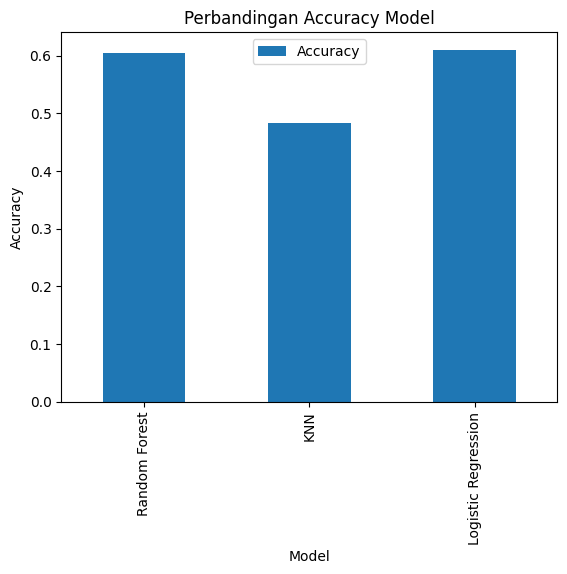

In [73]:
hasil.plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Perbandingan Accuracy Model')

plt.ylabel('Accuracy')

plt.show()

In [74]:
best_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42
)

best_model.fit(X, y)

print("\n===== MODEL TERBAIK =====")
print("Random Forest dipilih sebagai model terbaik")


===== MODEL TERBAIK =====
Random Forest dipilih sebagai model terbaik


Random Forest dipilih karena memiliki accuracy paling tinggi dibandingkan model lainnya.

Random Forest mampu:

menangani data kompleks
mengurangi overfitting
menghasilkan prediksi lebih stabil

In [75]:
print("\n===== PREDIKSI DATA TESTING =====")
test_features = test.drop('Id', axis=1)
test_pred = best_model.predict(test_features)

print(test_pred)


===== PREDIKSI DATA TESTING =====
[5 6 5 5 5 6 5 5 6 5 7 6 6 6 5 5 6 6 5 7 6 6 5 7 5 5 7 6 5 6 5 6 7 6 5 5 6
 6 6 6 6 6 6 5 5 5 5 6 5 6 7 5 6 7 6 7 6 6 6 5 5 6 6 7 6 6 6 5 5 5 7 5 5 6
 5 5 5 6 5 6 6 6 6 5 5 6 5 5 6 6 5 6 5 5 5 5 5 6 6 5 6 6 5 6 5 5 6 6 6 7 7
 5 5 6 5 5 6 6 6 5 5 5 5 6 5 5 6 6 5 6 5 5 7 6 7 5 5 5 6 6 7 5 5 5 6 5 5 5
 5 5 6 5 6 5 6 5 5 5 7 6 5 5 6 6 7 5 6 6 6 5 6 6 6 5 5 5 7 6 6 5 6 5 6 5 5
 5 7 5 6 6 6 6 7 6 6 6 5 6 7 6 6 6 5 6 7 7 5 5 6 6 5 6 5 6 5 6 6 5 7 5 5 6
 5 5 5 6 6 6 6 6 7 7 5 5 6 6 5 6 5 5 6 6 6 5 5 6 5 6 6 5 5 5 6 6 5 6 7 5 6
 5 5 6 7 6 5 5 6 6 5 6 6 7 5 6 5 6 5 6 5 5 5 6 5 5 5 7]


Model terbaik digunakan untuk memprediksi kualitas wine pada dataset testing.

Hasil prediksi berupa nilai quality untuk setiap data wine.

In [76]:
submission = pd.DataFrame({
    'Id': test['Id'],
    'Quality': test_pred
})

File submission dibuat sesuai ketentuan soal yaitu hanya berisi:

Id
Quality

In [77]:
print("\n===== HASIL PREDIKSI =====")

print(submission)


===== HASIL PREDIKSI =====
       Id  Quality
0     222        5
1    1514        6
2     417        5
3     754        5
4     516        5
5    1120        6
6     180        5
7      82        5
8     632        6
9     592        5
10    501        7
11   1586        6
12   1096        6
13   1101        6
14   1488        5
15    700        5
16    631        6
17   1022        6
18   1420        5
19    882        7
20   1170        6
21    911        6
22    124        5
23   1417        7
24    681        5
25     63        5
26   1010        7
27    418        6
28    399        5
29   1265        6
30    999        5
31    452        6
32    347        7
33    778        6
34    607        5
35     32        5
36    511        6
37   1035        6
38   1270        6
39    723        6
40    838        6
41    485        6
42    142        6
43   1470        5
44   1238        5
45    158        5
46    426        5
47    344        6
48    637        5
49   1578        6
50 